In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]

Original image size: 2756x1992
Rescaled image size: 1000x722


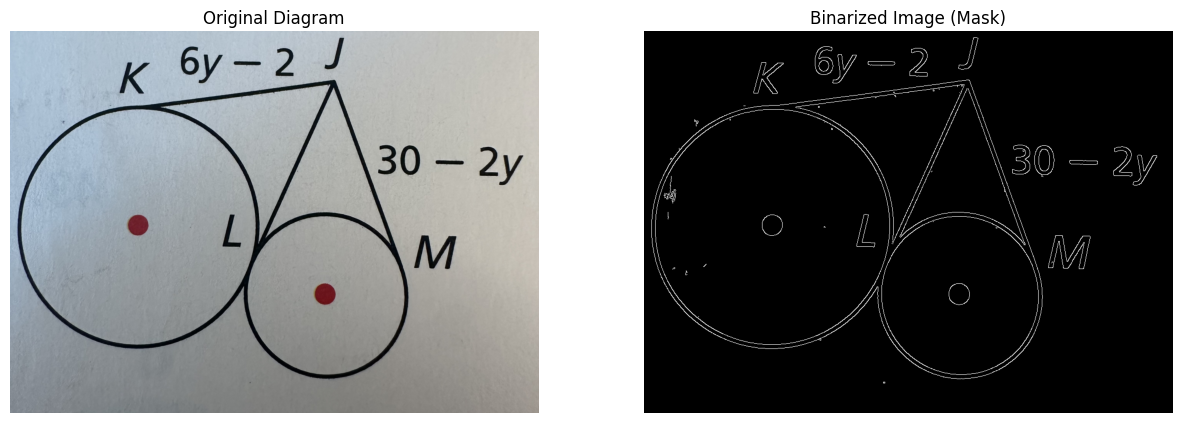

In [2]:
# load image and preprocess
img_bgr = cv2.imread('diagram_sample_image/circle7.jpg')

# scale image so that longest side is 1000 pixels
width, height = img_bgr.shape[1], img_bgr.shape[0]
max_dim = max(height, width)
scale_factor = 1000 / max_dim
img_bgr = cv2.resize(img_bgr, (int(width * scale_factor), int(height * scale_factor)), interpolation=cv2.INTER_AREA)
print(f"Original image size: {width}x{height}")
print(f"Rescaled image size: {img_bgr.shape[1]}x{img_bgr.shape[0]}")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
_, img_binary = cv2.threshold(img_blur, 127, 255, cv2.THRESH_BINARY_INV)
img_edge = cv2.Canny(img_gray, 50, 150, apertureSize=3)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original Diagram")
ax[0].axis('off')

ax[1].imshow(img_edge, cmap='gray')
ax[1].set_title("Binarized Image (Mask)")
ax[1].axis('off')
plt.show()

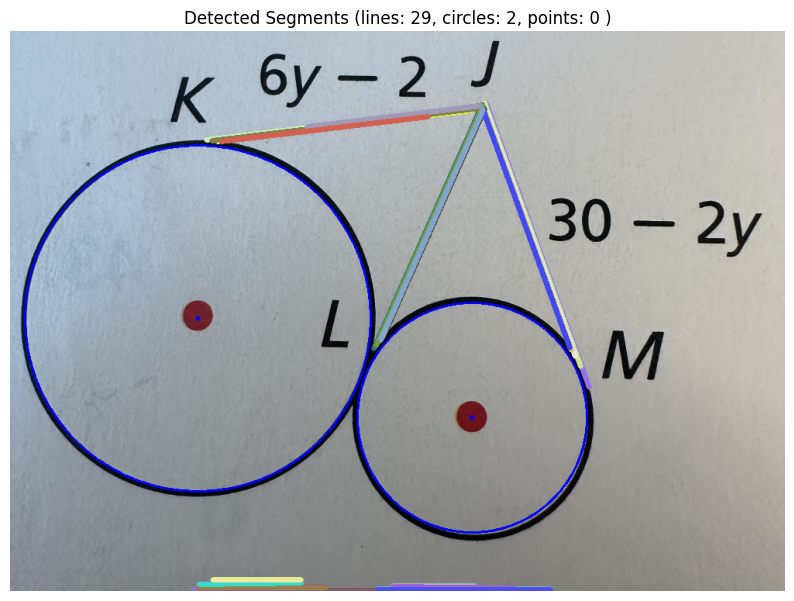

In [3]:
from draw_figures import draw_segments_on_image
from combine_geometry import mask_circles
circles = cv2.HoughCircles(
    img_blur, 
    cv2.HOUGH_GRADIENT, 
    dp=1, 
    minDist=200, 
    param1=100, 
    param2=50, 
    minRadius=100, 
    maxRadius=500
)

if circles is not None:
    cleaned_binary = mask_circles(img_binary, circles)
    lines = cv2.HoughLinesP(cleaned_binary, rho=1, theta=np.pi/180, threshold=250, minLineLength=100, maxLineGap=0)

else:
    lines = cv2.HoughLinesP(img_binary, rho=1, theta=np.pi/180, threshold=100, minLineLength=100, maxLineGap=0)
line_img = img_bgr.copy()


draw_segments_on_image(line_img, lines = lines, circles=circles)


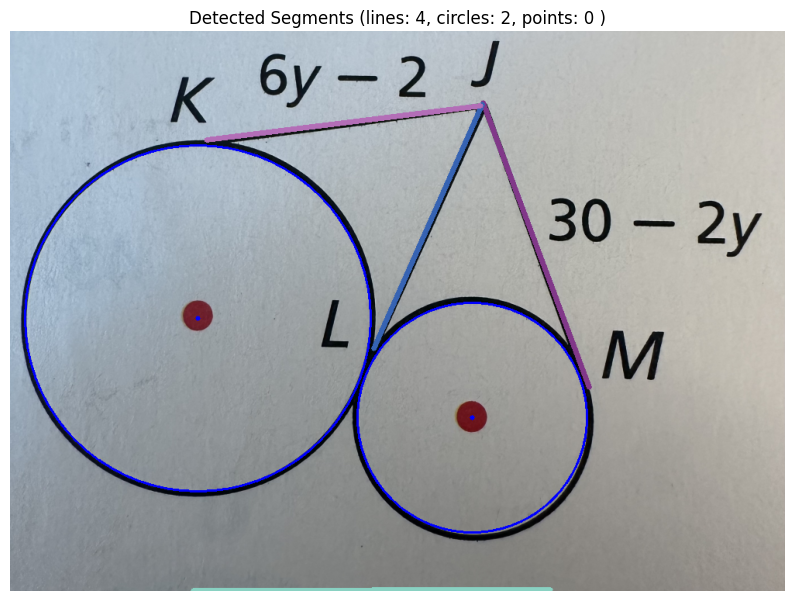

In [4]:
from combine_geometry import combine_lines

combined_lines = combine_lines(lines)
draw_segments_on_image(line_img, combined_lines, circles = circles if circles is not None else None)

Found 1 valid segment intersection points:


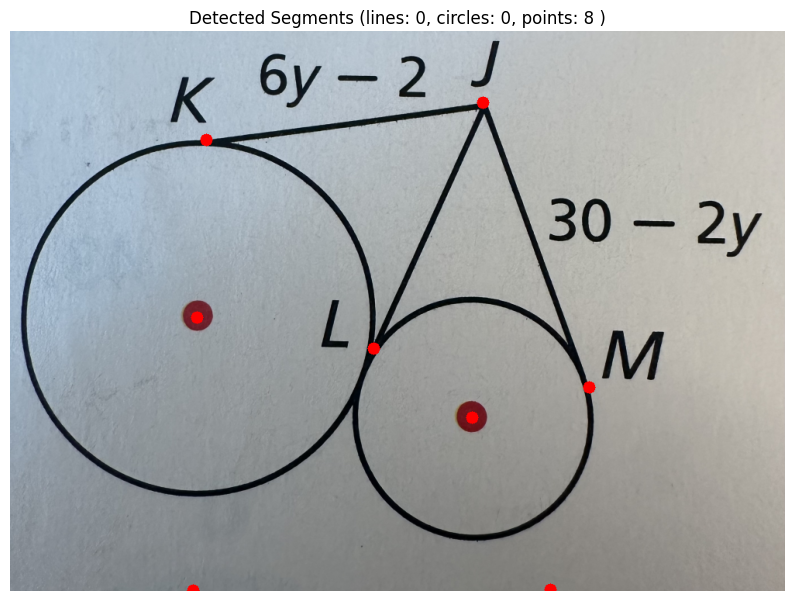

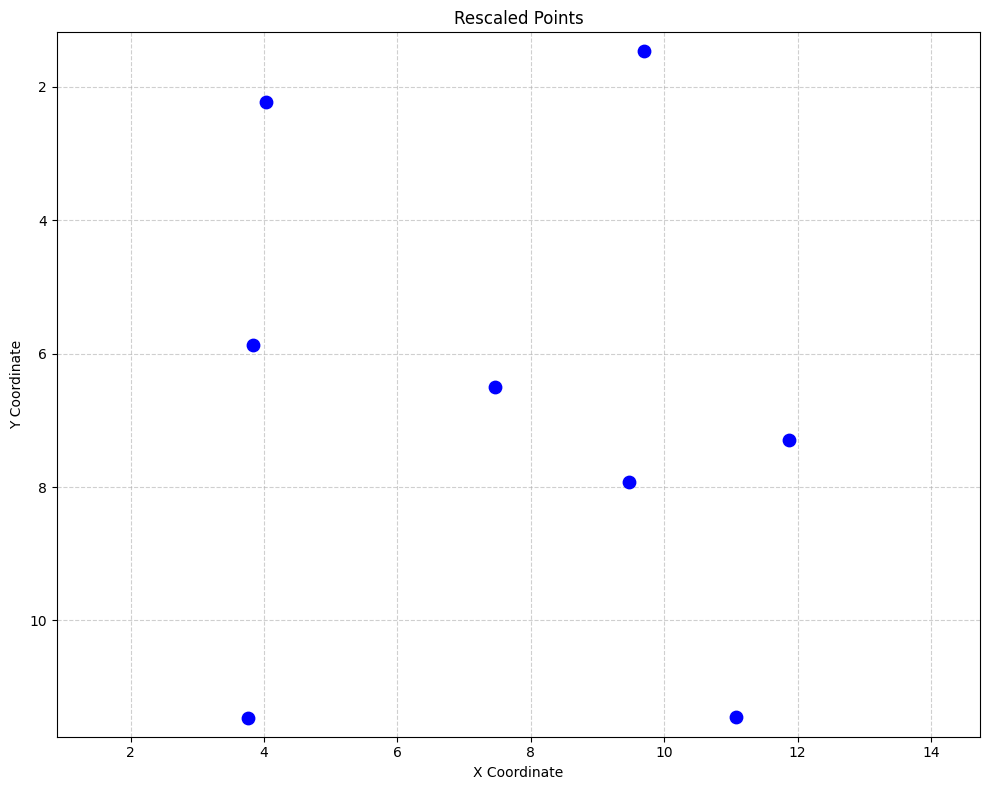

[(3.751987281399046, 11.462639109697932), (9.697933227344992, 1.4626391096979332), (7.456279809220985, 6.502384737678855), (4.022257551669316, 2.2257551669316373), (11.08108108108108, 11.446740858505564), (11.875993640699523, 7.2972972972972965), (3.83147853736089, 5.866454689984101), (9.475357710651828, 7.917329093799681)]


In [8]:
from draw_figures import draw_segments_on_image, plot_points
from combine_geometry import (get_all_intersection_points, get_distinct_points, rescale_points, align_points, force_align_points, get_all_tangency_points,get_line_circle_intersection_points)

# points from line ends
points = combined_lines.reshape(-1, 4)[:, :2].tolist()
points.extend(combined_lines.reshape(-1, 4)[:, 2:4].tolist())
# points from intersections
intersection_points = get_all_intersection_points(combined_lines)  
points.extend(intersection_points)

# points from circle & tangency
if circles is not None:
    circle_center_points = np.array(circles, dtype=np.float32).reshape(-1, 3)[:,:2]
    points.extend(circle_center_points)
    tangency_points = get_all_tangency_points(combined_lines, circles)
    points.extend(tangency_points)
    circle_intersection_points = get_line_circle_intersection_points(combined_lines, circles, threshold = -10)
    points.extend(circle_intersection_points)

distinct_points = get_distinct_points(points, threshold=60)
draw_segments_on_image(img_bgr, points=distinct_points)

rescaled_points = rescale_points(distinct_points)[0]

plot_points(rescaled_points, "Rescaled Points")
# aligned_points = force_align_points(rescaled_points)
# plot_points(aligned_points, "Aligned Points")
# print(aligned_points)
print(rescaled_points)